In [1]:
import sys 
from pathlib import Path

#Add the project root to the Python path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
from src.data import fetch_yahoo
from src.features import add_returns, add_momentum_signal, add_mean_reversion_signal, add_vol_regime
from src.backtest import backtest_long_only, backtest_long_only_with_regime


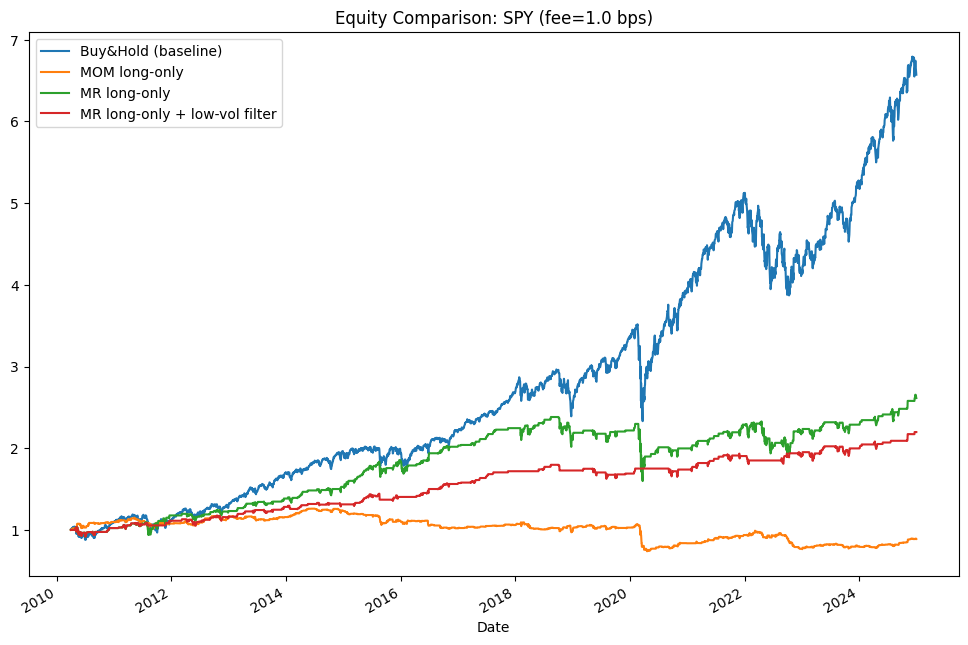

SPY {'Buy&Hold': 6.57202537023068, 'MOM_LO': 0.8895836377995284, 'MR_LO': 2.6141735158889086, 'MR_LO_lowvol': 2.1979825719083204}


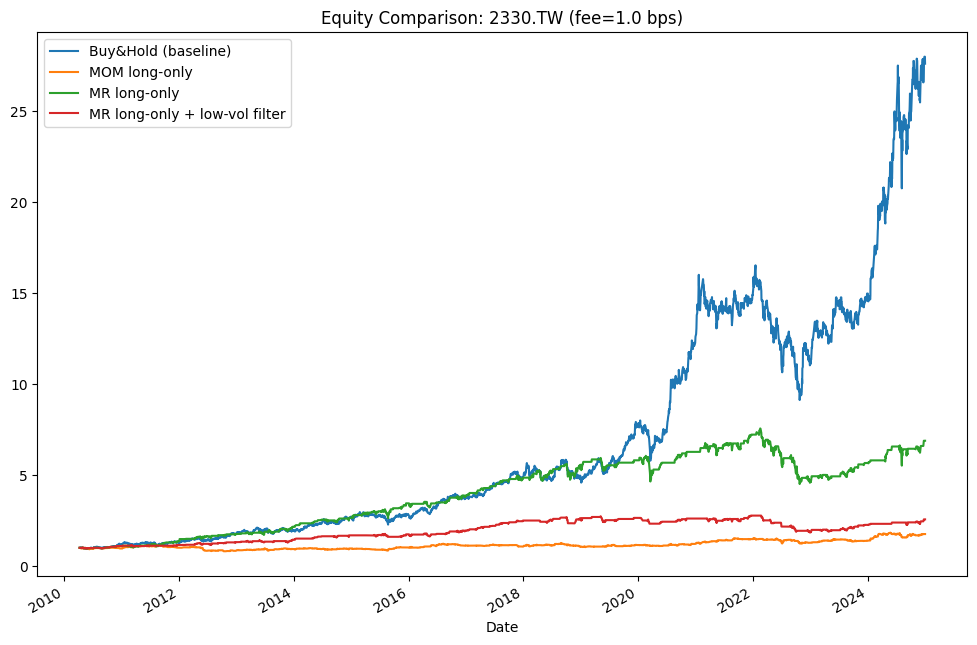

2330.TW {'Buy&Hold': 27.586594324235275, 'MOM_LO': 1.7567743132713727, 'MR_LO': 6.880595219644711, 'MR_LO_lowvol': 2.561850586067854}


In [3]:
FEE_BPS = 1.0
START, END = "2010-01-01", "2025-01-01"

def prepare(symbol):
    df = fetch_yahoo(symbol, START, END)
    df = add_returns(df)
    df = add_momentum_signal(df, lookback=60)
    df = add_mean_reversion_signal(df, z_window=20)
    df = add_vol_regime(df, vol_window=20, q=0.7)
    df = df.dropna()
    return df

def buy_and_hold_equity(df):
    #baseline: equity = cumprod(1 + ret)
    eq = (1.0 + df["ret_1d"].fillna(0.0)).cumprod()
    return eq

def run_symbol(symbol):
    df = prepare(symbol)
    eq_bh = buy_and_hold_equity(df)
    bt_mom_lo = backtest_long_only(df, "signal_mom", fee_bps=FEE_BPS)
    bt_mr_lo = backtest_long_only(df, "signal_mr", fee_bps=FEE_BPS)
    
    #Regime filter
    bt_mr_lo_reg = backtest_long_only_with_regime(
        df, signal_col="signal_mr", 
        regime_col="high_vol", 
        regime_active=0, 
        fee_bps=FEE_BPS)
    
    # Plot
    plt.figure(figsize=(12, 8))
    eq_bh.plot(label="Buy&Hold (baseline)")
    bt_mom_lo["equity"].plot(label="MOM long-only")
    bt_mr_lo["equity"].plot(label="MR long-only")
    bt_mr_lo_reg["equity"].plot(label="MR long-only + low-vol filter")
    plt.title(f"Equity Comparison: {symbol} (fee={FEE_BPS} bps)")
    plt.legend()
    plt.show()
    
    finals = {
        "Buy&Hold": float(eq_bh.iloc[-1]),
        "MOM_LO": float(bt_mom_lo["equity"].iloc[-1]),
        "MR_LO": float(bt_mr_lo["equity"].iloc[-1]),
        "MR_LO_lowvol": float(bt_mr_lo_reg["equity"].iloc[-1]),
    }
    return finals

for sym in ["SPY", "2330.TW"]:
    finals = run_symbol(sym)
    print(sym, finals)